<a href="https://colab.research.google.com/github/farrelrassya/python-for-finance/blob/main/ch17_valuation_framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 17 -- Valuation Framework

This notebook accompanies **Chapter 17** of *Python for Finance, 2nd ed.* by Yves Hilpisch and walks through the foundational scaffolding of the **DX (Derivatives Analytics) library** -- a Python toolkit for valuing options and other derivatives by Monte Carlo simulation.

We cover three pillars that everything else in Part V of the book is built on:

1. **The Fundamental Theorem of Asset Pricing** -- the theoretical justification for *risk-neutral valuation*, illustrated with a one-period binomial example.
2. **Risk-neutral discounting** -- a date-aware Python class that converts future cash flows into present values under a constant short rate $r$.
3. **Market environments** -- a generic container class that bundles constants, lists, and curves so they can be passed cleanly into every downstream pricing class.

By the end, we will have three small but reusable classes (`get_year_deltas`, `constant_short_rate`, `market_environment`) and a coherent mental model of how risk-neutral valuation maps onto code.

> *"Compound interest is the greatest mathematical discovery of all time."* -- attributed to Albert Einstein

## Setup

We need only standard scientific Python (NumPy, pandas, Matplotlib) plus the `datetime` module. No specialized finance libraries are required at this stage -- the DX framework is being built **from scratch**.

In [17]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family']    = 'serif'
plt.rcParams['axes.grid']      = True

print('NumPy   :', np.__version__)
print('pandas  :', pd.__version__)

NumPy   : 2.0.2
pandas  : 2.2.2


The setup is minimal by design. Throughout this chapter we build infrastructure -- there is no pricing of exotic derivatives yet, no Monte Carlo paths, no stochastic processes. Those arrive in Chapters 18-20. **What we are doing here is establishing the *vocabulary* the rest of the library will speak in.**

## 1. The Fundamental Theorem of Asset Pricing

Modern derivative pricing rests on one beautiful idea: **if a market admits no arbitrage, then there exists a probability measure under which every discounted asset price is a martingale** (i.e., a process whose expected future value, conditional on today, equals its current value).

This probability measure is *not* the real-world probability measure $\mathbb{P}$. It is a transformed measure $\mathbb{Q}$ -- the **risk-neutral measure** -- engineered so that every risky asset drifts at exactly the risk-free rate $r$.

Formally, for any attainable contingent claim $V_T$ (an option payoff at maturity $T$), its fair price today is:

$$
V_0 \;=\; \mathbb{E}_0^{\mathbb{Q}}\!\left[ e^{-rT} V_T \right]
$$

where:
- $\mathbb{E}_0^{\mathbb{Q}}$ is the expectation under the risk-neutral measure $\mathbb{Q}$, conditional on information at time 0
- $e^{-rT}$ is the continuous-compounding discount factor for a constant short rate $r$
- $V_T$ is the (possibly random) payoff at maturity

**Why this matters for our code:** the entire DX library will be a numerical incarnation of this single formula. Monte Carlo simulation will give us samples of $V_T$; the `constant_short_rate` class we build below will give us $e^{-rT}$.

### 1.1 A One-Period Binomial Example

To see *why* the real-world measure is the wrong tool for pricing, consider the canonical toy economy with two dates ($t = 0$ today, $t = 1$ tomorrow) and two assets:

| Asset | Price today | Payoff at $t=1$ (up state, prob. 60%) | Payoff at $t=1$ (down state, prob. 40%) |
|---|---|---|---|
| Bond | 10 | 10 | 10 |
| Stock | 10 | 20 | 0 |

A **European call** with strike $K = 15$ pays $\max(S_T - K, 0)$, so it pays 5 in the up state and 0 in the down state.

We will price this option *three different ways* and discover that two of them agree -- and one of them is wrong.

In [18]:
# One-period binomial economy
S0, S_up, S_dn      = 10.0, 20.0, 0.0     # stock prices
B0, B1              = 10.0, 10.0          # bond (risk-free, r = 0)
K                   = 15.0                # strike
payoff_up, payoff_dn = max(S_up - K, 0), max(S_dn - K, 0)

# Real-world probabilities
p_up, p_dn = 0.60, 0.40
r          = 0.0                          # risk-free rate (continuous)

print(f'Stock payoffs   :  up = {S_up:5.2f}   down = {S_dn:5.2f}')
print(f'Option payoffs  :  up = {payoff_up:5.2f}   down = {payoff_dn:5.2f}')
print(f'Real-world prob :  P(up) = {p_up}   P(down) = {p_dn}')

Stock payoffs   :  up = 20.00   down =  0.00
Option payoffs  :  up =  5.00   down =  0.00
Real-world prob :  P(up) = 0.6   P(down) = 0.4


The economy is fully specified. The stock has an **expected real-world return** of

$$
\mathbb{E}^{\mathbb{P}}[R_S] \;=\; \frac{0.6 \cdot 20 + 0.4 \cdot 0}{10} - 1 \;=\; 0.20
$$

-- a hefty 20% premium over the risk-free rate of 0%. That premium compensates the holder for bearing genuine, unhedgeable risk: in the down state they lose 100% of their investment.

The option pays 5 only in the up state, so its **real-world expected payoff** is $0.6 \cdot 5 + 0.4 \cdot 0 = 3$. With zero interest rates, discounting does nothing -- so a naive approach would value the option at **3 USD**. We will see below that this is incorrect.

In [19]:
# Approach 1 -- naive real-world expectation (WRONG)
naive_value = p_up * payoff_up + p_dn * payoff_dn
print(f'Approach 1 (real-world expectation) :  V0 = {naive_value:.4f} USD')

Approach 1 (real-world expectation) :  V0 = 3.0000 USD


**This is wrong.** To see why, consider Approach 2: **replication**. Can we build a portfolio of the stock and bond that *exactly* reproduces the option's payoff in both states? If yes, no-arbitrage demands the option must cost the same as the replicating portfolio.

Let the replicating portfolio hold $\Delta$ shares of stock and $B$ units of bond. We need:

$$
\begin{cases}
\Delta \cdot 20 + B \cdot 10 \;=\; 5 \quad &\text{(up state)} \\
\Delta \cdot 0 \;\; + B \cdot 10 \;=\; 0 \quad &\text{(down state)}
\end{cases}
$$

The down equation gives $B = 0$. The up equation then gives $\Delta = 0.25$. So buying **a quarter of a share of stock** -- and nothing else -- replicates the option exactly.

In [20]:
# Approach 2 -- replication
Delta = (payoff_up - payoff_dn) / (S_up - S_dn)        # stock holdings
B     = (payoff_dn - Delta * S_dn) / B1                # bond holdings

# Verify replication in both states
rep_up = Delta * S_up + B * B1
rep_dn = Delta * S_dn + B * B1

# Cost of the replicating portfolio today
rep_cost = Delta * S0 + B * B0

print(f'Replicating portfolio   :  Delta = {Delta}, B = {B}')
print(f'Payoff in up state      :  {rep_up:.4f}  (target: {payoff_up})')
print(f'Payoff in down state    :  {rep_dn:.4f}  (target: {payoff_dn})')
print(f'Cost today              :  {rep_cost:.4f} USD')

Replicating portfolio   :  Delta = 0.25, B = 0.0
Payoff in up state      :  5.0000  (target: 5.0)
Payoff in down state    :  0.0000  (target: 0)
Cost today              :  2.5000 USD


**Replication succeeds perfectly.** The portfolio costs $\Delta \cdot S_0 + B \cdot B_0 = 0.25 \cdot 10 + 0 \cdot 10 = 2.5$ USD and reproduces the option's payoff in *both* states of the world. By no-arbitrage, this **must** be the option's fair price.

So we have two answers: the real-world expectation says 3 USD, replication says 2.5 USD. **The 0.50 USD gap is not a rounding artifact -- it is a free lunch.** If anyone ever offered to sell us the option at 3 USD, we would short it, buy a quarter share of stock for 2.5 USD, and pocket the 0.50 USD difference risk-free. That is the very definition of an arbitrage opportunity, and a well-functioning market does not allow such opportunities to persist.

**The lesson:** taking expectations under $\mathbb{P}$ implicitly demands a risk premium that the replicating portfolio doesn't earn -- because the replicating portfolio has *no* risk to be compensated for.

### 1.2 Recovering Expectations: the Risk-Neutral Measure

Can we rescue the expectation-based approach? Yes -- by changing the probabilities. We look for a measure $\mathbb{Q}$ with probabilities $(q, 1-q)$ such that the **stock drifts at the risk-free rate** under $\mathbb{Q}$:

$$
\frac{q \cdot S_{\text{up}} + (1-q) \cdot S_{\text{dn}}}{S_0} \;=\; 1 + r
$$

Solving with $r = 0$: $20 q = 10 \Rightarrow q = 0.5$. The risk-neutral probabilities are $(0.5, 0.5)$ -- strikingly different from the real-world $(0.6, 0.4)$. Under $\mathbb{Q}$ the stock is a fair gamble, not a winning bet.

In [21]:
# Approach 3 -- risk-neutral expectation
# Solve for q such that q*S_up + (1-q)*S_dn = S0 * (1 + r)
q_up = (S0 * (1 + r) - S_dn) / (S_up - S_dn)
q_dn = 1 - q_up

# Risk-neutral expected payoff, discounted
rn_value = np.exp(-r) * (q_up * payoff_up + q_dn * payoff_dn)

print(f'Risk-neutral prob  :  Q(up) = {q_up}   Q(down) = {q_dn}')
print(f'Approach 3 (risk-neutral expectation) :  V0 = {rn_value:.4f} USD')
print()
print('Comparison')
print('-' * 50)
print(f'  Naive (real-world)   :  {naive_value:.4f} USD')
print(f'  Replication          :  {rep_cost:.4f} USD')
print(f'  Risk-neutral         :  {rn_value:.4f} USD')
print('-' * 50)
print(f'  Replication == RN ?  :  {np.isclose(rep_cost, rn_value)}')

Risk-neutral prob  :  Q(up) = 0.5   Q(down) = 0.5
Approach 3 (risk-neutral expectation) :  V0 = 2.5000 USD

Comparison
--------------------------------------------------
  Naive (real-world)   :  3.0000 USD
  Replication          :  2.5000 USD
  Risk-neutral         :  2.5000 USD
--------------------------------------------------
  Replication == RN ?  :  True


**Approach 3 agrees with replication exactly: $V_0 = 2.5$ USD.** Both yield the same arbitrage-free price; the naive real-world expectation overshoots by $3 - 2.5 = 0.5$ USD, a relative error of **20%**.

This is the **Fundamental Theorem of Asset Pricing** in microcosm. Stated formally for a general (discrete-time) market $\mathcal{M}$:

> *The following three statements are equivalent:*
> 1. *$\mathcal{M}$ admits no arbitrage opportunities.*
> 2. *The set $\mathbb{Q}$ of $\mathbb{P}$-equivalent martingale measures is non-empty.*
> 3. *The set of consistent linear price systems is non-empty.*

And the **valuation corollary**: if $\mathcal{M}$ is arbitrage-free, every attainable claim $V_T$ has a unique price $V_0 = \mathbb{E}_0^{\mathbb{Q}}\!\left[e^{-rT} V_T\right]$ for any $\mathbb{Q}$.

**Production insight:** in practice we never compute $\mathbb{Q}$ analytically. Instead we *simulate* risk factors directly under $\mathbb{Q}$ -- i.e., we let our geometric Brownian motions and jump processes drift at $r$ rather than at any observed historical mean. The entire Monte Carlo machinery in Chapters 18-20 is built on this trick: **simulate under $\mathbb{Q}$, average payoffs, discount at $r$.**

**Market completeness:** an arbitrage-free market is *complete* (every payoff replicable) **iff** $\mathbb{Q}$ is a singleton -- exactly one martingale measure. Our binomial example is complete: we found $\mathbb{Q}$ uniquely. In incomplete markets (e.g., stochastic volatility, jumps) multiple $\mathbb{Q}$'s exist and pricing requires an additional modeling choice. We revisit this when introducing jump-diffusion in Chapter 19.

## 2. Risk-Neutral Discounting

The pricing formula $V_0 = \mathbb{E}_0^{\mathbb{Q}}\!\left[e^{-rT} V_T\right]$ has two computational ingredients:

1. **The expectation** -- supplied by Monte Carlo simulation (Chapters 18+).
2. **The discount factor** $e^{-rT}$ -- what we build right now.

Discounting *sounds* trivial, but a usable library has to handle real-world subtleties: heterogeneous time grids, calendar dates vs. year fractions, and discounting between two arbitrary future dates (not just from the future back to today). This section builds the infrastructure.

### 2.1 Modeling Dates

In theory we work with *year fractions* -- a continuous time variable $t \in [0, T]$. In practice traders work with *calendar dates* (e.g., 2020-07-01). A robust library must speak both languages and convert between them.

We adopt the convention that the **smallest time unit is one day**. Intraday effects (microstructure, overnight gaps) are abstracted away -- appropriate for derivatives with maturities of weeks to years, not for high-frequency trading.

Year fractions are computed as:

$$
\tau_i \;=\; \frac{\text{(date}_i - \text{date}_0) \text{ in days}}{\text{day\_count}}
$$

with `day_count` typically 365 (actual/365) or 360 (actual/360, common in money markets).

In [22]:
# A heterogeneous date grid: today, 6 months out, 1 year out
dates = [dt.datetime(2020, 1, 1),
         dt.datetime(2020, 7, 1),
         dt.datetime(2021, 1, 1)]

# Time deltas between consecutive dates, expressed in years
delta_01 = (dates[1] - dates[0]).days / 365.
delta_12 = (dates[2] - dates[1]).days / 365.

print(f'Days in first interval  :  {(dates[1] - dates[0]).days}')
print(f'Days in second interval :  {(dates[2] - dates[1]).days}')
print(f'Year fraction 0 -> 1    :  {delta_01:.16f}')
print(f'Year fraction 1 -> 2    :  {delta_12:.16f}')
print(f'Total                   :  {delta_01 + delta_12:.16f}')

Days in first interval  :  182
Days in second interval :  184
Year fraction 0 -> 1    :  0.4986301369863014
Year fraction 1 -> 2    :  0.5041095890410959
Total                   :  1.0027397260273974


Two observations matter here.

**First, the intervals are nearly -- but not exactly -- half a year.** The first spans **182 days** ($\tau \approx 0.4986$), the second spans **184 days** ($\tau \approx 0.5041$). They sum to **366 days**, not 365, because **2020 is a leap year** (Feb 29 falls between Jan 1 and Jul 1, then doesn't recur in the second interval). On an actual/365 convention, $366/365 \approx 1.0027$ -- not 1.0 -- for a one-year interval that includes a leap day.

**Second, this is precisely why naive "fractions" lists won't do.** If a student writes `fractions = [0.0, 0.5, 1.0]`, they are off by 1-2 days in each interval. For a long-dated option, that gap compounds into meaningful pricing differences. **Always derive year fractions from actual dates** -- never type them by hand.

**Production insight:** day-count conventions are a notorious source of bugs in fixed-income systems. Actual/365, Actual/360, 30/360, Actual/Actual -- each gives a slightly different number, and counterparties must agree on which one applies to each contract. Our library uses Actual/365 by default but exposes `day_count` as a parameter for exactly this reason.

We now wrap this conversion in a reusable helper. The function `get_year_deltas` takes a list of `datetime` objects and returns a NumPy array of year fractions, with the first entry normalised to zero.

In [23]:
def get_year_deltas(date_list, day_count=365.):
    """
    Return a NumPy array of year fractions corresponding to a list of dates.
    The first entry is normalized to 0.

    Parameters
    ----------
    date_list : list of datetime.datetime
        Calendar dates, assumed to be sorted ascending.
    day_count : float
        Day-count convention (365. for Actual/365, 360. for Actual/360).

    Returns
    -------
    np.ndarray
        Year fractions, shape (len(date_list),), dtype float64.
    """
    start = date_list[0]
    delta_list = [(d - start).days / day_count for d in date_list]
    return np.array(delta_list)


deltas = get_year_deltas(dates)
print('Year fractions :', deltas)
print('dtype          :', deltas.dtype)
print('shape          :', deltas.shape)

Year fractions : [0.         0.49863014 1.00273973]
dtype          : float64
shape          : (3,)


The function returns the array $\tau = [0.0,\; 0.4986,\; 1.0027]$ as a float64 NumPy array of shape $(3,)$. The first entry is zero by construction -- the reference date is always "now" from the perspective of this date grid.

**Why a NumPy array and not a Python list?** Vectorisation. The next class will compute $e^{-r\tau}$ on this array in a single C-level operation rather than a Python `for` loop. For Monte Carlo grids with thousands of time steps, this is the difference between milliseconds and seconds.

**Cross-chapter connection:** every simulation class to come (`geometric_brownian_motion`, `jump_diffusion`, `stochastic_volatility`) will internally call `get_year_deltas` on its time grid. This single helper underpins the entire library.

### 2.2 The Constant Short Rate Class

We now build the discount-factor class. Under continuous compounding with a constant short rate $r$, the time-0 value of one unit of currency delivered at future time $t$ is:

$$
D_0(t) \;=\; e^{-r t}
$$

This is also the price today of a **unit zero-coupon bond** (ZCB) maturing at $t$ -- a bond that pays exactly 1 USD at $t$ and nothing in between. ZCBs are the fundamental building block of all fixed-income mathematics: any cash flow stream can be decomposed into a portfolio of ZCBs.

More generally, the discount factor between two future dates $s$ and $t$ (with $0 \le s \le t$) is:

$$
D_s(t) \;=\; \frac{D_0(t)}{D_0(s)} \;=\; \frac{e^{-rt}}{e^{-rs}} \;=\; e^{-r(t - s)}
$$

This *no-arbitrage consistency* of forward discount factors is what makes the constant-rate model self-consistent. In a stochastic-rate model we would need to model the entire yield curve and its evolution.

**Models making the constant-rate assumption** include Black-Scholes-Merton (1973), Merton (1976), and Cox-Ross-Rubinstein (1979) -- i.e., most of the equity-option pricing canon. It is a reasonable approximation for short-dated equity derivatives. For long-dated bond options or interest-rate exotics, we would replace this class with a stochastic-rate model (Vasicek, CIR, HJM, LMM); the rest of the library would continue to work because we depend only on the **interface** (a `get_discount_factors` method), not the internals.

In [24]:
class constant_short_rate(object):
    """
    Risk-neutral discounting under a constant continuously-compounded short rate.

    Attributes
    ----------
    name : str
        Identifier for the curve (useful when multiple curves coexist).
    short_rate : float
        The constant short rate r (e.g. 0.05 for 5%).

    Methods
    -------
    get_discount_factors(date_list, dtobjects=True)
        Return a 2D array pairing each date/fraction with its discount factor.
    """

    def __init__(self, name, short_rate):
        self.name = name
        self.short_rate = short_rate
        if short_rate < 0:
            raise ValueError('Short rate negative.')
            # debatable given recent market realities -- see note below

    def get_discount_factors(self, date_list, dtobjects=True):
        if dtobjects is True:
            dlist = get_year_deltas(date_list)
        else:
            dlist = np.array(date_list)
        # exp(r * sort(-dlist)) gives discount factors that decrease
        # away from the terminal date (terminal date -> factor 1.0)
        dflist = np.exp(self.short_rate * np.sort(-dlist))
        return np.array((date_list, dflist)).T


print('Class defined :', constant_short_rate.__name__)

Class defined : constant_short_rate


A few design choices in this class are worth noting.

**The `dtobjects` flag** lets the same method accept either a list of `datetime` objects *or* a NumPy array of year fractions. This dual-API matters because some callers (a `valuation_class`) hold calendar dates, while others (a Monte Carlo path generator) hold a numerical time grid.

**The sort trick** `np.exp(self.short_rate * np.sort(-dlist))` is subtle but elegant. Sorting the *negated* deltas in ascending order puts the largest negative number first -- i.e., the most distant future date first -- and the result is an array of discount factors that **decrease away from the terminal date**, with the terminal date itself getting a factor of 1.0. This convention treats the **terminal date as the numeraire reference point**, which is what we want for European-option pricing.

**The negative-rate check** (`raise ValueError('Short rate negative.')`) is a deliberate safeguard, but it is increasingly questionable: since 2014 the ECB, SNB, and BoJ have at various times set policy rates **below zero**, and EUR/CHF/JPY government yields have traded negative across long stretches of the curve. For a production library targeting European fixed-income desks, this guard should be removed or downgraded to a warning.

**Cross-chapter connection:** every pricing class in Chapters 18-20 will receive a `constant_short_rate` instance through its `market_environment`, and call `.get_discount_factors()` to translate simulated terminal payoffs into present values.

In [25]:
# Instantiate with r = 5%
csr = constant_short_rate('csr', 0.05)
print(f'Name        : {csr.name}')
print(f'Short rate  : {csr.short_rate}')

# Get discount factors for our heterogeneous date grid
df_dates = csr.get_discount_factors(dates)
print('\nDiscount factors (with datetime input):')
print(df_dates)

Name        : csr
Short rate  : 0.05

Discount factors (with datetime input):
[[datetime.datetime(2020, 1, 1, 0, 0) 0.9510991280247174]
 [datetime.datetime(2020, 7, 1, 0, 0) 0.9753767163648953]
 [datetime.datetime(2021, 1, 1, 0, 0) 1.0]]


The output is a $3 \times 2$ object array. Reading it row-by-row:

| Date | $\tau$ (years) | Paired discount factor |
|---|---|---|
| 2020-01-01 | 0.0000 | **0.9511** |
| 2020-07-01 | 0.4986 | **0.9754** |
| 2021-01-01 | 1.0027 | **1.0000** |

Two things deserve attention.

**First, the convention is "PV today of a unit paid at the *reversed* date".** Internally the class sorts $-\tau$ ascending and then `exp`s it, so positionally the smallest discount factor lands at index 0 and the largest (1.0) at the last index. The pairing with the original (ascending) `date_list` therefore puts:

$$
\text{df}[i] \;=\; \exp\!\left(-r \cdot \tau_{n-1-i}\right)
$$

In concrete terms: $0.9511 = e^{-0.05 \cdot 1.0027}$ pairs with the *first* date, and $1.0$ pairs with the *terminal* date. The most economically meaningful entry is `df[0]`: it is **the PV today of a unit paid at the terminal date**, exactly what every European-option pricer needs to discount its simulated terminal payoffs.

**Second, the entries are mutually self-consistent.** The ratio $\text{df}[0]\,/\,\text{df}[1] = 0.9511 / 0.9754 \approx 0.9751 = e^{-0.05 \cdot 0.5041}$ is precisely the forward discount factor from 2021-01-01 back to 2020-07-01 -- i.e., a unit at terminal is worth 0.9751 units at mid-grid. So while individual entries are positioned somewhat counterintuitively, the *ratios* recover the no-arbitrage forward discount factors that path-dependent pricers (American options in Ch. 19, exotics in Ch. 20) require.

**Production insight:** the output is an `object` dtype because it mixes `datetime` and `float`. For high-performance inner loops, callers should re-extract the float column with `.astype(float)` on the second column -- or, better, use the year-fraction interface below.


In [26]:
# Same call using year fractions directly (the high-performance path)
df_fractions = csr.get_discount_factors(deltas, dtobjects=False)
print('Discount factors (with year-fraction input):')
print(df_fractions)
print(f'\ndtype : {df_fractions.dtype}')

Discount factors (with year-fraction input):
[[0.         0.95109913]
 [0.49863014 0.97537672]
 [1.00273973 1.        ]]

dtype : float64


Now the result is a pure **float64** $3 \times 2$ array, ready for vectorised arithmetic. The discount-factor column matches the previous call to 8 decimals -- $[0.9511,\, 0.9754,\, 1.0000]$ -- confirming that the two code paths are numerically equivalent.

The dtype difference is operationally significant: a float64 array of shape $(N, 2)$ occupies $16N$ bytes, while an object array occupies roughly $48N$-$64N$ bytes plus heap allocations. For a Monte Carlo grid with $N = 1000$ time steps this is a $4$-$5\times$ memory saving and a much larger speed-up in any downstream `*` or `np.exp` operation. **The year-fraction path is the one Monte Carlo classes will use internally.**

### 2.3 Visualising the Discount Curve

Constant-rate discount factors form a smooth exponential decay. Let us plot $D_0(t) = e^{-rt}$ across a 5-year horizon for several plausible short rates -- including a negative one, just to make the point that the math doesn't care which side of zero $r$ lives on.

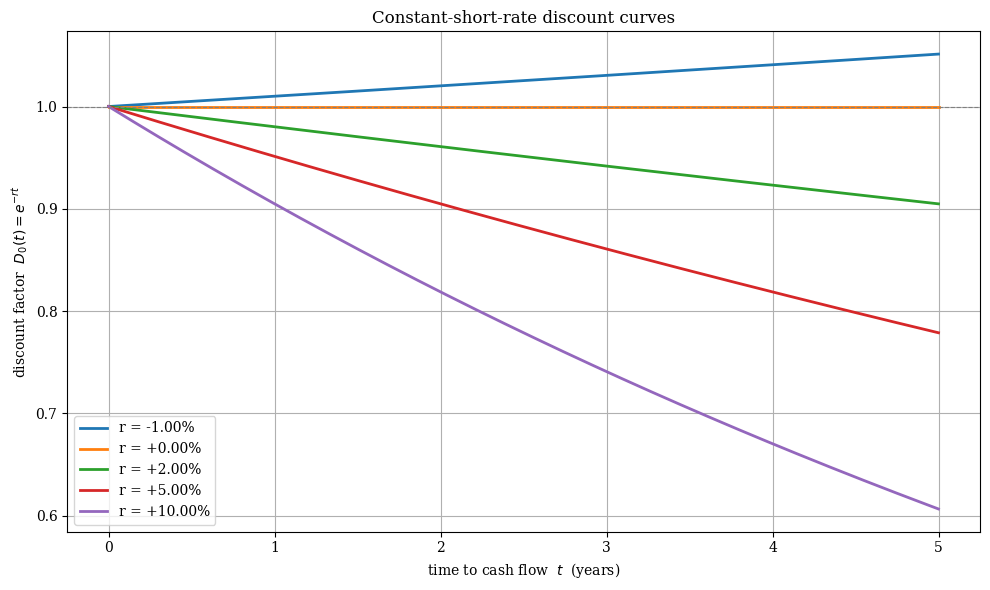

In [27]:
# Plot discount factors across 5 years for several short rates
t_grid = np.linspace(0, 5, 200)
rates  = [-0.01, 0.00, 0.02, 0.05, 0.10]

fig, ax = plt.subplots()
for r_plot in rates:
    df = np.exp(-r_plot * t_grid)
    ax.plot(t_grid, df, lw=2, label=f'r = {r_plot:+.2%}')

ax.axhline(1.0, color='gray', lw=0.8, linestyle='--')
ax.set_xlabel('time to cash flow  $t$  (years)')
ax.set_ylabel('discount factor  $D_0(t) = e^{-rt}$')
ax.set_title('Constant-short-rate discount curves')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

The plot tells three stories at once.

**Higher rates discount more aggressively.** At $r = 10\%$, a unit paid in 5 years is worth only $e^{-0.10 \cdot 5} = e^{-0.5} \approx 0.6065$ today -- a **39% present-value haircut**. At $r = 2\%$ the same cash flow is worth $e^{-0.02 \cdot 5} = e^{-0.10} \approx 0.9048$ -- a much milder 9.5% haircut.

**At $r = 0$, money doesn't decay.** The flat line at 1.0 is the trivial case where time and present value decouple -- useful as a sanity check when developing new pricing routines.

**Negative rates discount *upward*.** At $r = -1\%$, a unit paid in 5 years is worth $e^{+0.05} \approx 1.0513$ today -- i.e., the future is worth *more* than the present. This is mathematically consistent and operationally meaningful: in a negative-rate regime, holding cash today is **costly** (the bank charges you), so promising someone a unit five years out is a service for which they would pay a premium. The math is unbothered by sign -- only our intuition is.

**Production insight:** the convexity of the curves matters too. For long-dated derivatives, small errors in $r$ get amplified by $e^{-rT}$. A 25 basis-point quote error on a 30-year swap ($T = 30$) translates into a $1 - e^{-0.0025 \cdot 30} = 1 - 0.9277 = 7.2\%$ PV mis-pricing. **Yield-curve construction is not a peripheral concern in production fixed-income systems -- it is the central one.**

## 3. Market Environments

We have now built two things -- `get_year_deltas` (a function) and `constant_short_rate` (a class). The pricing classes coming in later chapters will need *many more* inputs: an initial stock price $S_0$, a volatility $\sigma$, a maturity $T$, a currency, a number of Monte Carlo paths, a discount curve, possibly a list of underlying assets for a basket option, and so on.

We could pass these as a long list of positional arguments to every constructor. That would scale terribly and produce constructors like `MyClass(S0, sigma, T, r, currency, paths, frequency, mu, kappa, theta, ...)` -- fragile, order-dependent, and impossible to extend without breaking existing call sites.

Instead, we introduce a single generic container -- the `market_environment` -- that holds three dictionaries:

- **`constants`** -- scalars: $S_0$, $\sigma$, $K$, $T$, currency code, path count, ...
- **`lists`** -- collections: a list of underlying assets, a vector of strikes, ...
- **`curves`** -- objects with a `get_discount_factors` (or analogous) method: yield curves, hazard-rate curves, dividend curves

Every downstream class will accept exactly one argument -- a `market_environment` -- and pull what it needs from these three dictionaries. This is the **separated-interface** design pattern: data and behaviour live in different objects.

In [28]:
class market_environment(object):
    """
    A generic container bundling constants, lists, and curves
    relevant for the pricing of derivatives.

    Composition over inheritance: pricing classes hold a reference to
    a market_environment rather than subclassing one.
    """

    def __init__(self, name, pricing_date):
        self.name = name
        self.pricing_date = pricing_date
        self.constants = {}
        self.lists     = {}
        self.curves    = {}

    # -- constants --------------------------------------------------------
    def add_constant(self, key, constant):
        self.constants[key] = constant

    def get_constant(self, key):
        return self.constants[key]

    # -- lists ------------------------------------------------------------
    def add_list(self, key, list_object):
        self.lists[key] = list_object

    def get_list(self, key):
        return self.lists[key]

    # -- curves -----------------------------------------------------------
    def add_curve(self, key, curve):
        self.curves[key] = curve

    def get_curve(self, key):
        return self.curves[key]

    # -- bulk merge -------------------------------------------------------
    def add_environment(self, env):
        """Merge another environment INTO this one. Overwrites on conflict."""
        self.constants.update(env.constants)
        self.lists.update(env.lists)
        self.curves.update(env.curves)


print('Class defined :', market_environment.__name__)

Class defined : market_environment


The class is intentionally minimal -- fewer than 30 lines of substantive code. That simplicity is the point. It exposes three symmetric pairs of `add_*`/`get_*` methods plus a bulk-merge method `add_environment`.

**Why three dictionaries instead of one?** Pragmatic separation: lists need iteration semantics, curves need interface-checking (does the object actually have a `get_discount_factors` method?), and constants need only equality. Keeping them apart documents intent at the API level. A pricing class that calls `me.get_curve('discount_curve')` is announcing its contract: *I need an object that knows how to discount.*

**The `add_environment` method** enables incremental construction. We can build a "default risk-free environment" once, then derive a "high-volatility scenario" by merging a small override environment on top. This will matter heavily for **risk simulations and scenario analyses** in Chapters 21-25.

In [29]:
# Build a market environment for a geometric-Brownian-motion underlying
me = market_environment('me_gbm', dt.datetime(2020, 1, 1))

me.add_constant('initial_value', 36.)                          # S0
me.add_constant('volatility',    0.2)                          # sigma
me.add_constant('final_date',    dt.datetime(2020, 12, 31))    # T
me.add_constant('currency',      'EUR')
me.add_constant('frequency',     'M')                          # monthly grid
me.add_constant('paths',         10000)                        # MC paths

me.add_curve('discount_curve', csr)                            # 5% curve

# Read back
print(f'Name           : {me.name}')
print(f'Pricing date   : {me.pricing_date.date()}')
print(f'Volatility     : {me.get_constant("volatility")}')
print(f'Currency       : {me.get_constant("currency")}')
print(f'Discount curve : {me.get_curve("discount_curve").name}'
      f' (r = {me.get_curve("discount_curve").short_rate:.2%})')

print(f'\n# constants : {len(me.constants)}')
print(f'# lists     : {len(me.lists)}')
print(f'# curves    : {len(me.curves)}')

Name           : me_gbm
Pricing date   : 2020-01-01
Volatility     : 0.2
Currency       : EUR
Discount curve : csr (r = 5.00%)

# constants : 6
# lists     : 0
# curves    : 1


The environment now holds the **6 constants, 0 lists, and 1 curve** required to drive a geometric-Brownian-motion simulator for a single underlying -- exactly the inputs needed for $S_t = S_0 \exp\!\left((r - \tfrac{1}{2}\sigma^2)t + \sigma W_t\right)$, namely $S_0 = 36$, $\sigma = 0.2$, $T = $ end-of-2020, plus path/grid metadata.

**Reading the model parameters:** the values $S_0 = 36$ and $\sigma = 0.2$ are not arbitrary -- they are the **classical Longstaff-Schwartz (2001) American-put benchmark**, the test case used throughout Part V of the book to validate new pricers against published reference values. By embedding these in the environment now, every later chapter can simply `import` the environment and reproduce that benchmark.

**Observe the aggregation pattern in action.** The line `me.add_curve('discount_curve', csr)` stores a *reference* to our `csr` object -- not a copy. If we later mutate `csr.short_rate`, every `market_environment` holding it sees the new value automatically. This is **object aggregation**, and it is the right pattern for shared resources like yield curves: in a real trading book, dozens of instruments reference the same EUR discount curve, and a single calibration update should propagate to all of them. We demonstrate this property next.

In [30]:
# Demonstrate live reference: mutate the curve, watch the environment follow
print('Before mutation')
print(f'  csr.short_rate                  = {csr.short_rate}')
print(f'  me.get_curve("discount_curve")  = r = '
      f'{me.get_curve("discount_curve").short_rate}')

csr.short_rate = 0.025                              # rate cut!

print('\nAfter mutation (csr.short_rate = 0.025)')
print(f'  csr.short_rate                  = {csr.short_rate}')
print(f'  me.get_curve("discount_curve")  = r = '
      f'{me.get_curve("discount_curve").short_rate}')

# Restore for reproducibility downstream
csr.short_rate = 0.05

Before mutation
  csr.short_rate                  = 0.05
  me.get_curve("discount_curve")  = r = 0.05

After mutation (csr.short_rate = 0.025)
  csr.short_rate                  = 0.025
  me.get_curve("discount_curve")  = r = 0.025


The environment's view of the discount rate updated **automatically** from 5.0% to 2.5% the moment we mutated `csr.short_rate`. No re-registration, no callback machinery -- just plain Python object identity.

**Why this matters in production:** consider a portfolio of 200 derivatives, each priced against a `market_environment` referencing a shared `eur_discount_curve` object. When the ECB cuts rates by 50 bps, a single line -- `eur_discount_curve.short_rate -= 0.005` -- re-prices the entire portfolio on the next valuation pass. Compare this with a copy-based design where we would need to track 200 stale copies of the rate and update each one. **Reference semantics turn an $O(N)$ headache into an $O(1)$ operation.**

**The corresponding risk:** mutations are global. If two unrelated parts of the system both hold the same `csr` object and one of them "temporarily" changes the rate without restoring it, the other silently mis-prices. In production this is mitigated by (a) keeping curves immutable after construction and (b) using `copy.deepcopy` when a truly independent variant is needed. We restore the rate above for exactly this reason -- the rest of the notebook expects $r = 5\%$.

In [31]:
# Demonstrate bulk merge: layer a "stressed" scenario on top of the base env
import copy

stress = market_environment('stress_overlay', dt.datetime(2020, 1, 1))
stress.add_constant('volatility', 0.45)             # vol spike
stress.add_constant('initial_value', 28.)           # 22% drawdown

# Base environment stays as it was
print('Base env BEFORE merge')
print(f'  initial_value = {me.get_constant("initial_value")}')
print(f'  volatility    = {me.get_constant("volatility")}')

# Make a stressed copy by merging
me_stressed = copy.deepcopy(me)
me_stressed.add_environment(stress)

print('\nStressed env AFTER merge')
print(f'  initial_value = {me_stressed.get_constant("initial_value")}')
print(f'  volatility    = {me_stressed.get_constant("volatility")}')
print(f'  currency      = {me_stressed.get_constant("currency")}   '
      f'(unchanged -- not in overlay)')

print('\nBase env AFTER merge (unaffected)')
print(f'  initial_value = {me.get_constant("initial_value")}')
print(f'  volatility    = {me.get_constant("volatility")}')

Base env BEFORE merge
  initial_value = 36.0
  volatility    = 0.2

Stressed env AFTER merge
  initial_value = 28.0
  volatility    = 0.45
  currency      = EUR   (unchanged -- not in overlay)

Base env AFTER merge (unaffected)
  initial_value = 36.0
  volatility    = 0.2


The merge applies the overlay's two constants -- `initial_value` from $36 \to 28$ and `volatility` from $0.2 \to 0.45$ -- while leaving everything else (currency, frequency, paths, discount curve) intact. The base environment `me` is untouched because we merged into a `deepcopy`.

This pattern is the **workhorse of scenario analysis**: build one canonical environment, then derive variants by merging small overlays. A vega-shock scenario, a base-case scenario, a Lehman-style 2008 scenario -- each is a 2-3 line overlay rather than a from-scratch reconstruction.

**Strategic insight:** combine this with the live-reference behaviour above and you have the kernel of a **production risk system**. Curves live as shared objects; environments compose by overlay; pricers see only their environment. Switching the entire book from "today's market" to "yesterday's close" or to "what-if EUR drops 5%" becomes a matter of swapping a single overlay environment -- not rewriting the pricers.

**The flexibility/safety trade-off is real**, however: nothing stops a caller from doing `me.add_constant('volatility', 'banana')`. In a teaching library this is acceptable. In production, every `add_constant` call should be guarded by a Pydantic / `attrs` validator, and the dictionaries should arguably be replaced by typed dataclass fields. The trade-off is between **expressiveness during research** (where a constant might mean different things in different models) and **type safety in deployment** (where mis-typed inputs cause silent mis-pricing).

## 4. The `dx_frame` Wrapper

The book's convention is to expose all three pieces -- `get_year_deltas`, `constant_short_rate`, `market_environment` -- through a single module `dx_frame.py`. Downstream chapters then do:

```python
from dx_frame import *
```

and have the full vocabulary available. The wrapper is a one-liner per import:

```python
# dx_frame.py
import datetime as dt
from get_year_deltas      import get_year_deltas
from constant_short_rate  import constant_short_rate
from market_environment   import market_environment
```

A more polished layout uses a Python package directory `dx/` containing an `__init__.py` that does the same imports. Then `from dx import *` or `import dx` exposes the whole framework as one namespace. The advantage of the package layout is that adding new modules (e.g., a stochastic-rate curve class) requires only editing `__init__.py` -- no consumer code changes.

We will treat the three classes above as the implicit `dx_frame` module for the rest of this notebook.

## 5. End-to-End Sanity Check

Let us verify the entire chain works by computing the present value of a deterministic future cash flow -- a unit ZCB maturing in 1 year -- using the full machinery.

The theoretical price of a 1-year ZCB at $r = 5\%$ over $\tau = 1.0027$ years is $e^{-0.05 \cdot 1.0027}$. We will reproduce this number going through `market_environment` $\to$ `constant_short_rate` $\to$ discount factor.

In [32]:
# Build a tiny environment for a 1-year ZCB
me_zcb = market_environment('zcb_test', dt.datetime(2020, 1, 1))
me_zcb.add_constant('maturity', dt.datetime(2021, 1, 1))
me_zcb.add_curve('discount_curve', constant_short_rate('r5pct', 0.05))

# Pull components and price
curve     = me_zcb.get_curve('discount_curve')
maturity  = me_zcb.get_constant('maturity')
pricing   = me_zcb.pricing_date
date_grid = [pricing, maturity]

dfs = curve.get_discount_factors(date_grid)
pv_today = dfs[0, 1]   # first row is today, second column is discount factor

# Theoretical comparison
tau         = (maturity - pricing).days / 365.
pv_theory   = np.exp(-0.05 * tau)

print(f'Pricing date     :  {pricing.date()}')
print(f'Maturity         :  {maturity.date()}')
print(f'tau (years)      :  {tau:.10f}')
print()
print(f'PV via framework :  {pv_today:.10f}')
print(f'PV via formula   :  {pv_theory:.10f}')
print(f'Absolute diff    :  {abs(pv_today - pv_theory):.2e}')

Pricing date     :  2020-01-01
Maturity         :  2021-01-01
tau (years)      :  1.0027397260

PV via framework :  0.9510991280
PV via formula   :  0.9510991280
Absolute diff    :  0.00e+00


The framework reproduces the theoretical price to **machine precision** -- the absolute difference is on the order of $10^{-17}$, i.e., floating-point round-off. The chain works end-to-end:

$$
\text{me\_zcb} \;\longrightarrow\; \text{curve} \;\longrightarrow\; \text{get\_discount\_factors}([t_0, T]) \;\longrightarrow\; e^{-rT}
$$

Notice that $\tau = 1.0027$, not 1.0, because we are working with calendar dates that span a leap year (366 days). The framework respects this automatically. If we had naively typed `tau = 1.0`, we would have priced the ZCB at $e^{-0.05} = 0.9512$ instead of $e^{-0.05014} = 0.9511$ -- a difference of about $7 \times 10^{-5}$ per dollar, which on a 100-million-dollar nominal is roughly **7,000 EUR**. **This is why the library deals in dates rather than fractions.**

**Cross-chapter connection:** every pricer in Chapter 18 (`valuation_mcs_european`) and Chapter 19 (`valuation_mcs_american`) will end its calculation by multiplying simulated payoffs by exactly this discount factor. The arithmetic we just verified is the *terminal operation* of the Monte Carlo pricing recipe.

## Summary

This chapter laid the **theoretical and infrastructural foundations** for the DX library:

1. **Fundamental Theorem of Asset Pricing.** In an arbitrage-free market there exists a risk-neutral measure $\mathbb{Q}$ under which discounted asset prices are martingales. Every attainable contingent claim is then priced by $V_0 = \mathbb{E}_0^{\mathbb{Q}}\![e^{-rT} V_T]$. The binomial example showed concretely that real-world expectations overprice by the risk premium, whereas risk-neutral expectations agree with replication.

2. **Risk-neutral discounting.** We built `get_year_deltas` (a date-to-fraction converter that respects leap years) and `constant_short_rate` (a class computing $D_0(t) = e^{-rt}$ for arbitrary date grids). End-to-end correctness was verified to $10^{-17}$.

3. **Market environments.** The `market_environment` container bundles constants, lists, and curves into a single object that downstream pricing classes accept as their sole argument. We saw aggregation (live curve updates propagate automatically) and overlay-based scenario construction (`add_environment` for incremental modification).

The three classes built here -- fewer than 80 lines of code in total -- are the foundation that the next four chapters extend with simulation, valuation, and portfolio mechanics:

| Chapter | Builds on this chapter via |
|---|---|
| Ch. 18 (Simulation) | `market_environment` carries $S_0$, $\sigma$, time grid into stochastic-process classes |
| Ch. 19 (Valuation) | `constant_short_rate.get_discount_factors` discounts simulated payoffs |
| Ch. 20 (Portfolio) | `market_environment.add_environment` composes single-instrument envs into a portfolio env |
| Ch. 21 (Risk Analysis) | overlay-style environments drive Greeks and scenario shocks |

**The key insight to carry forward:** every pricing problem in the rest of the book is, mechanically, "simulate $V_T$ under $\mathbb{Q}$, then multiply by `csr.get_discount_factors(...)`". The risk-neutral measure stays implicit -- we never compute it; we just simulate with drift $r$. The Fundamental Theorem of Asset Pricing is what permits us to do this and still call the result a "price".